# Taxol Concentration Classification

#  XcepKNN Model

### Author: Sean Fletcher, Ethan Gilles

---

## Importing libraries

In [1]:
import random
import torchvision
import torch
import torch.nn as nn
import timm
import torchvision.models as models
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
from torchinfo import summary

# Cuda Drivers

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.device(device)

device(type='cuda')

# Data loading

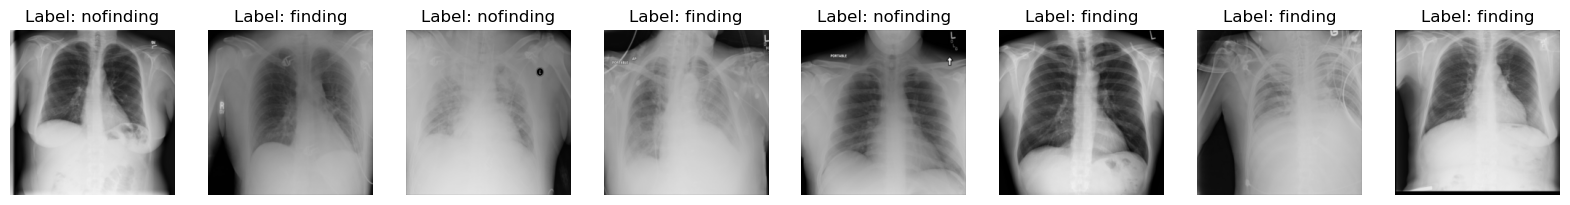

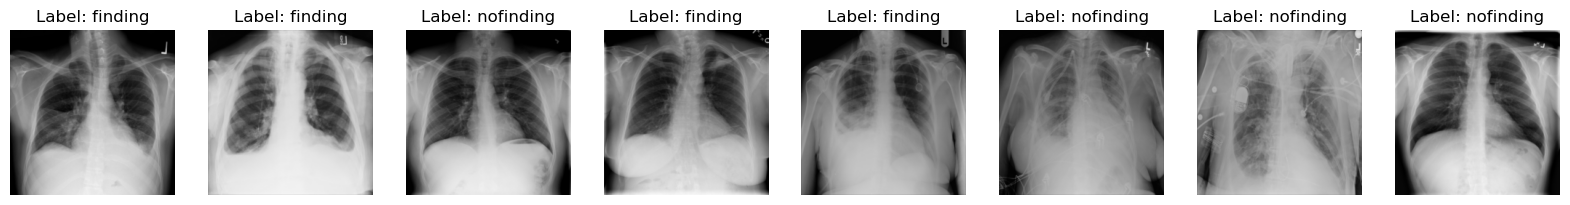

In [3]:
transform = transforms.Compose([
    transforms.Resize((227, 227)),  
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize images
])

batch_size=16

train_dataset = datasets.ImageFolder(root='sorted_subset/training', transform=transform)
test_dataset = datasets.ImageFolder(root='sorted_subset/testing', transform=transform)


# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

def visualize_images(dataset, num_images=5):
    plt.figure(figsize=(20, 3))

    random_indices = random.sample(range(len(dataset)), num_images)

    for i, idx in enumerate(random_indices):
        image, label = dataset[idx]  # Get the image and label
        image = image.numpy().transpose((1, 2, 0))  # Convert from CxHxW to HxWxC
        image = (image * 0.5) + 0.5  # Undo normalization for visualization

        # Plot the image
        plt.subplot(1, num_images, i + 1)
        plt.imshow(image)
        plt.title(f'Label: {dataset.classes[label]}')
        plt.axis('off')

    plt.show()


visualize_images(train_dataset, num_images=8)
visualize_images(test_dataset, num_images=8)

# Create the Xception-KNN Hybrid

In [4]:
def create_feature_extractor():
    base_model = timm.create_model('xception', pretrained=True, num_classes=0)  # No final layer
    model = nn.Sequential(
        base_model,
        nn.Flatten(),
        nn.Dropout(0.3),
        nn.Linear(base_model.num_features, 128),
        nn.ReLU(),
        nn.Dropout(0.2),
        # Remove the final classification layer (softmax)
    )
    return model.to(device)

feature_extractor = create_feature_extractor()
feature_extractor.load_state_dict(torch.load('xception_model_weights.pth'), strict=False)
feature_extractor.eval()

summary(model=feature_extractor, input_size=(32, 3, 227, 227))

/home/ethan/.local/lib/python3.12/site-packages/timm/models/_factory.py:126: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(
/tmp/ipykernel_552964/1004357240.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded f

Layer (type:depth-idx)                        Output Shape              Param #
Sequential                                    [32, 128]                 --
├─Xception: 1-1                               [32, 2048]                --
│    └─Conv2d: 2-1                            [32, 32, 113, 113]        864
│    └─BatchNorm2d: 2-2                       [32, 32, 113, 113]        64
│    └─ReLU: 2-3                              [32, 32, 113, 113]        --
│    └─Conv2d: 2-4                            [32, 64, 111, 111]        18,432
│    └─BatchNorm2d: 2-5                       [32, 64, 111, 111]        128
│    └─ReLU: 2-6                              [32, 64, 111, 111]        --
│    └─Block: 2-7                             [32, 128, 56, 56]         --
│    │    └─Sequential: 3-1                   [32, 128, 56, 56]         26,816
│    │    └─Conv2d: 3-2                       [32, 128, 56, 56]         8,192
│    │    └─BatchNorm2d: 3-3                  [32, 128, 56, 56]         256
│    └

## K-Fold Cross Validation Training

5 folds with a batch size of 32

In [6]:
# Hyperparameters
batch_size = 16
k_folds = 5
num_neighbors = 5
minkowski_p = 2

# Define the K-Fold Cross Validator
kfold = KFold(n_splits=k_folds, shuffle=True)

# Lists to store metrics for each fold
train_accuracies = []
val_accuracies = []
class_reports = []
class_names = ['Finding', 'No Finding' ]

for fold, (train_ids, val_ids) in enumerate(kfold.split(train_dataset)):
    print(f'FOLD {fold + 1}')
    print('--------------------------------')

    # Create data loaders for the current fold
    train_subsampler = Subset(train_dataset, train_ids)
    val_subsampler = Subset(train_dataset, val_ids)
    train_loader = DataLoader(train_subsampler, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_subsampler, batch_size=batch_size, shuffle=False)

    # Extract features from the training set
    train_features = []
    train_labels = []
    with torch.no_grad():
        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            features = feature_extractor(inputs)
            train_features.append(features.cpu().numpy())
            train_labels.append(labels.numpy())
    train_features = np.concatenate(train_features, axis=0)
    train_labels = np.concatenate(train_labels, axis=0)

    # Extract features from the validation set
    val_features = []
    val_labels = []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            features = feature_extractor(inputs)
            val_features.append(features.cpu().numpy())
            val_labels.append(labels.numpy())
    val_features = np.concatenate(val_features, axis=0)
    val_labels = np.concatenate(val_labels, axis=0)

    # Train KNN classifier with Minkowski distance
    knn = KNeighborsClassifier(n_neighbors=num_neighbors, p=minkowski_p)
    knn.fit(train_features, train_labels)

    # Compute training accuracy
    train_preds = knn.predict(train_features)
    train_accuracy = accuracy_score(train_labels, train_preds)
    train_accuracies.append(train_accuracy)

    # Compute validation accuracy
    val_preds = knn.predict(val_features)
    val_accuracy = accuracy_score(val_labels, val_preds)
    val_accuracies.append(val_accuracy)

    # Store classification report for this fold
    class_reports.append(classification_report(val_labels, val_preds, output_dict=True))

    print(f'Training Accuracy: {train_accuracy * 100:.2f}%')
    print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')

# Compute macro and weighted averages
macro_accuracy_avg = np.mean(train_accuracies + val_accuracies)
weighted_accuracy_avg = np.average(
    train_accuracies + val_accuracies,
    weights=[len(train_ids)] * k_folds + [len(val_ids)] * k_folds
)

# Print final metrics
print('\nFinal Metrics:')
print(f'Training Accuracy (Avg): {np.mean(train_accuracies) * 100:.2f}%')
print(f'Validation Accuracy (Avg): {np.mean(val_accuracies) * 100:.2f}%')
print(f'Macro Accuracy Avg: {macro_accuracy_avg * 100:.2f}%')
print(f'Weighted Accuracy Avg: {weighted_accuracy_avg * 100:.2f}%')

print("\nClassification Report for Last Fold:")
print(classification_report(val_labels, val_preds, target_names=class_names))

print('Finished Cross-Validation')

FOLD 1
--------------------------------
Training Accuracy: 79.19%
Validation Accuracy: 70.32%
FOLD 2
--------------------------------
Training Accuracy: 78.91%
Validation Accuracy: 69.72%
FOLD 3
--------------------------------
Training Accuracy: 78.72%
Validation Accuracy: 71.85%
FOLD 4
--------------------------------
Training Accuracy: 78.70%
Validation Accuracy: 70.27%
FOLD 5
--------------------------------
Training Accuracy: 78.52%
Validation Accuracy: 71.70%

Final Metrics:
Training Accuracy (Avg): 78.81%
Validation Accuracy (Avg): 70.77%
Macro Accuracy Avg: 74.79%
Weighted Accuracy Avg: 77.20%

Classification Report for Last Fold:
              precision    recall  f1-score   support

     Finding       0.71      0.67      0.69       949
  No Finding       0.72      0.76      0.74      1069

    accuracy                           0.72      2018
   macro avg       0.72      0.71      0.71      2018
weighted avg       0.72      0.72      0.72      2018

Finished Cross-Validation


## Testing XcepKNN

In [7]:
from tabulate import tabulate  

# Extract features from the test set
test_features = []
test_labels = []
feature_extractor.eval()
with torch.no_grad():
    for inputs, labels in DataLoader(test_dataset, batch_size=batch_size, shuffle=False):
        inputs = inputs.to(device)
        features = feature_extractor(inputs)
        test_features.append(features.cpu().numpy())
        test_labels.append(labels.numpy())

test_features = np.concatenate(test_features, axis=0)
test_labels = np.concatenate(test_labels, axis=0)

# Make predictions on the test set
test_preds = knn.predict(test_features)

# Compute metrics
test_accuracy = accuracy_score(test_labels, test_preds)
test_precision_weighted = precision_score(test_labels, test_preds, average='weighted')
test_recall_weighted = recall_score(test_labels, test_preds, average='weighted')
test_f1_weighted = f1_score(test_labels, test_preds, average='weighted')
test_precision_macro = precision_score(test_labels, test_preds, average='macro')
test_recall_macro = recall_score(test_labels, test_preds, average='macro')
test_f1_macro = f1_score(test_labels, test_preds, average='macro')

# Get classification report
class_report = classification_report(test_labels, test_preds, output_dict=True, target_names=class_names)

# Extract per-class statistics
class_stats = []
for class_name in class_report.keys():
    if class_name in ['macro avg', 'weighted avg', 'accuracy']:
        continue
    class_stats.append([
        class_name,
        round(class_report[class_name]['precision'], 4),
        round(class_report[class_name]['recall'], 4),
        round(class_report[class_name]['f1-score'], 4),
        int(class_report[class_name]['support']),  # Support is an integer
    ])

# Add macro and weighted averages
class_stats.append([
    "Testing Macro Avg",
    round(test_precision_macro, 4),
    round(test_recall_macro, 4),
    round(test_f1_macro, 4),
    int(class_report['macro avg']['support']),  # Support is an integer
])
class_stats.append([
    "Testing Weighted Avg",
    round(test_precision_weighted, 4),
    round(test_recall_weighted, 4),
    round(test_f1_weighted, 4),
    int(class_report['weighted avg']['support']),  # Support is an integer
])

# Add overall test performance metrics
class_stats.append([
    "Testing Overall Metrics",
    round(test_precision_weighted, 4),
    round(test_recall_weighted, 4),
    round(test_f1_weighted, 4),
    len(test_labels),  # Total number of test samples
])

# Print the table with four decimal places
headers = ["Class", "Precision", "Recall", "F1 Score", "Support"]
print(tabulate(class_stats, headers=headers, tablefmt="grid", floatfmt=".4f"))

# Print additional metrics (if needed)
print(f"Test Accuracy: {test_accuracy:.4f}") 
print(f"Macro Accuracy Avg: {test_precision_macro:.4f}") 
print(f"Weighted Accuracy Avg: {test_precision_weighted:.4f}") 

+-------------------------+-------------+----------+------------+-----------+
| Class                   |   Precision |   Recall |   F1 Score |   Support |
+=========================+=============+==========+============+===========+
| Finding                 |      0.6253 |   0.6035 |     0.6142 |       517 |
+-------------------------+-------------+----------+------------+-----------+
| No Finding              |      0.6699 |   0.6899 |     0.6797 |       603 |
+-------------------------+-------------+----------+------------+-----------+
| Testing Macro Avg       |      0.6476 |   0.6467 |     0.6470 |      1120 |
+-------------------------+-------------+----------+------------+-----------+
| Testing Weighted Avg    |      0.6493 |   0.6500 |     0.6495 |      1120 |
+-------------------------+-------------+----------+------------+-----------+
| Testing Overall Metrics |      0.6493 |   0.6500 |     0.6495 |      1120 |
+-------------------------+-------------+----------+------------

## Confusion Matrix

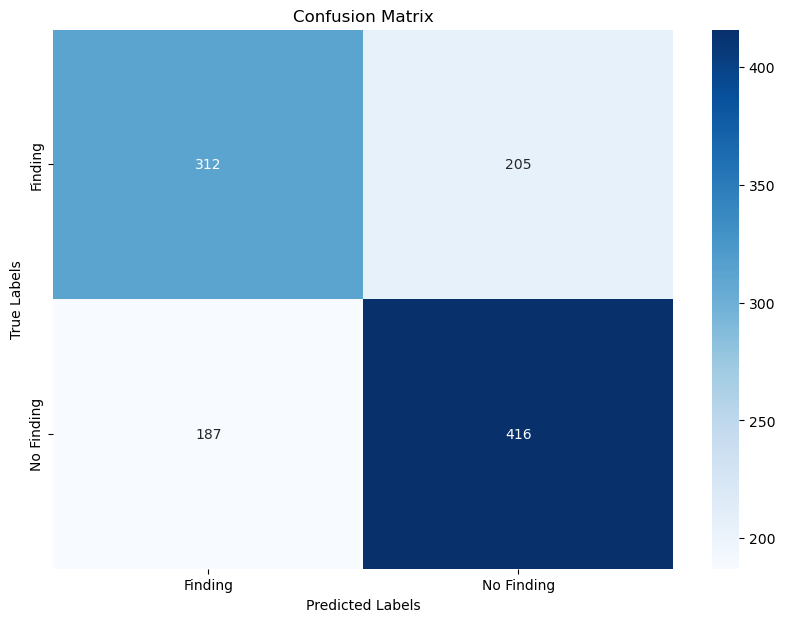

In [8]:
import seaborn as sns
# Compute the confusion matrix
cm = confusion_matrix(test_labels, test_preds)

# Plot the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()